In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots



## Read the data and display the first 5 rows

In [ ]:
data=pd.read_csv("Data\online_retail_cleaned.csv")
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth,Day,DayOfWeek,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,15.30,2010-12,1,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,2010-12,1,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,22.00,2010-12,1,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,2010-12,1,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,2010-12,1,Wednesday,8


### Product Insights

#### Top Selling Products by Revenue

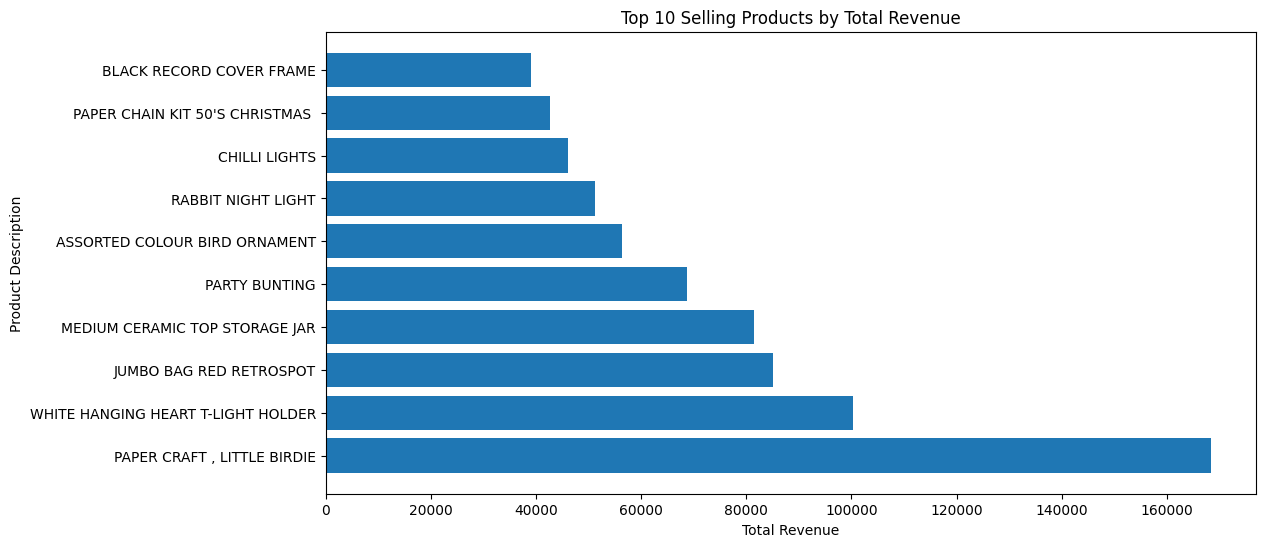

In [3]:
top_selling_products = data.groupby('Description')['TotalPrice'].sum().nlargest(10)

plt.figure(figsize=(12, 6))
plt.barh(y=top_selling_products.index, width=top_selling_products.values)
plt.title('Top 10 Selling Products by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.show()

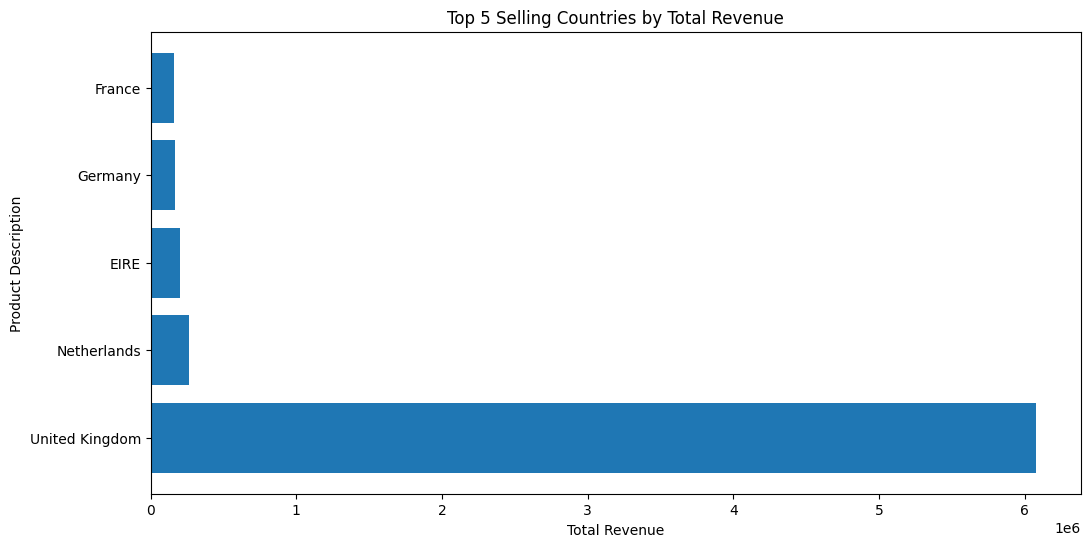

In [4]:
top_countries = data.groupby('Country')['TotalPrice'].sum().nlargest(5)

plt.figure(figsize=(12, 6))
plt.barh(y=top_countries.index, width=top_countries.values)
plt.title('Top 5 Selling Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.show()

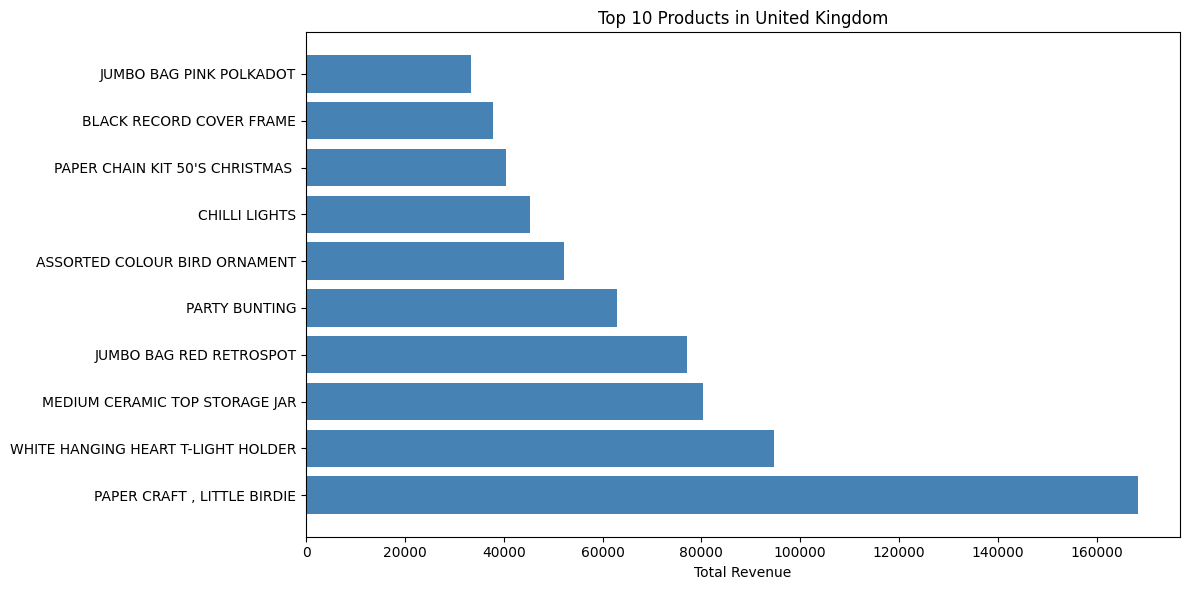

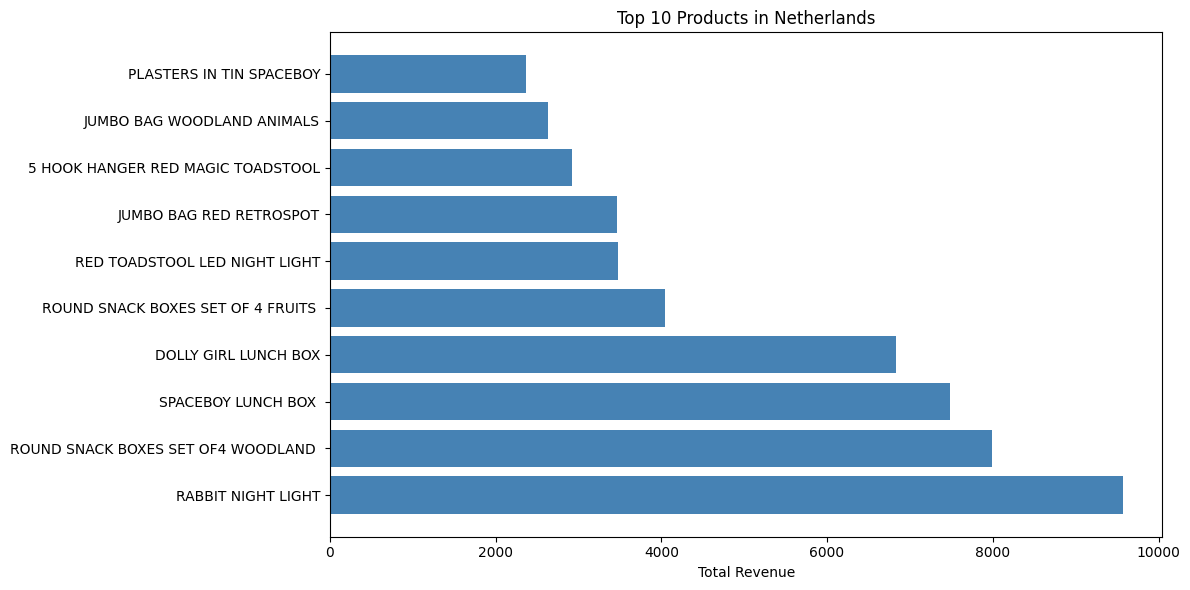

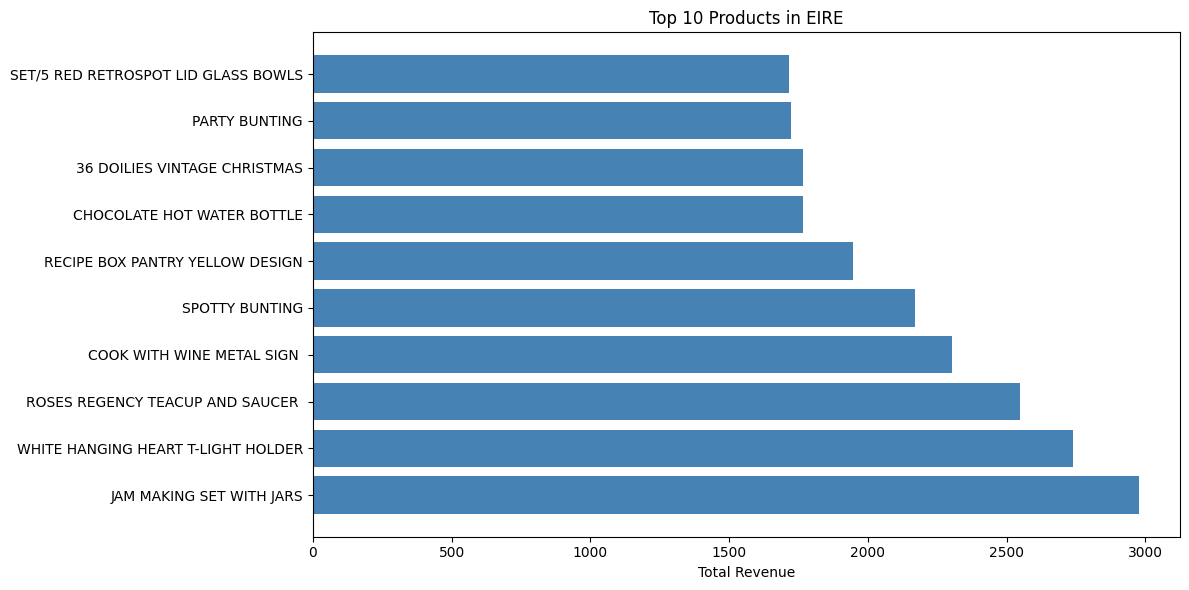

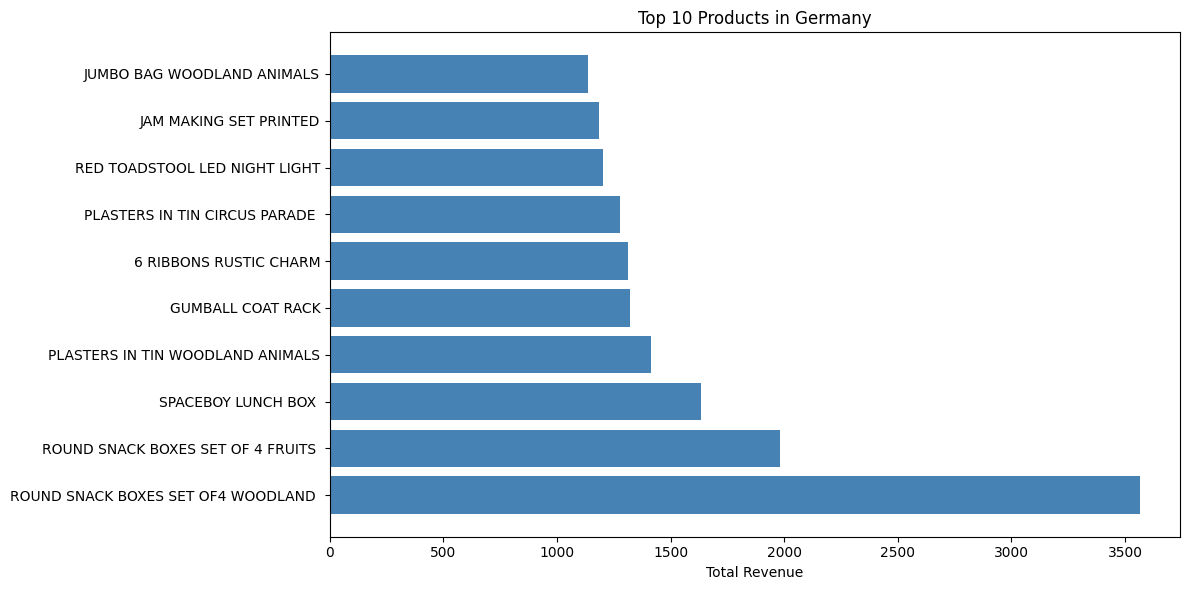

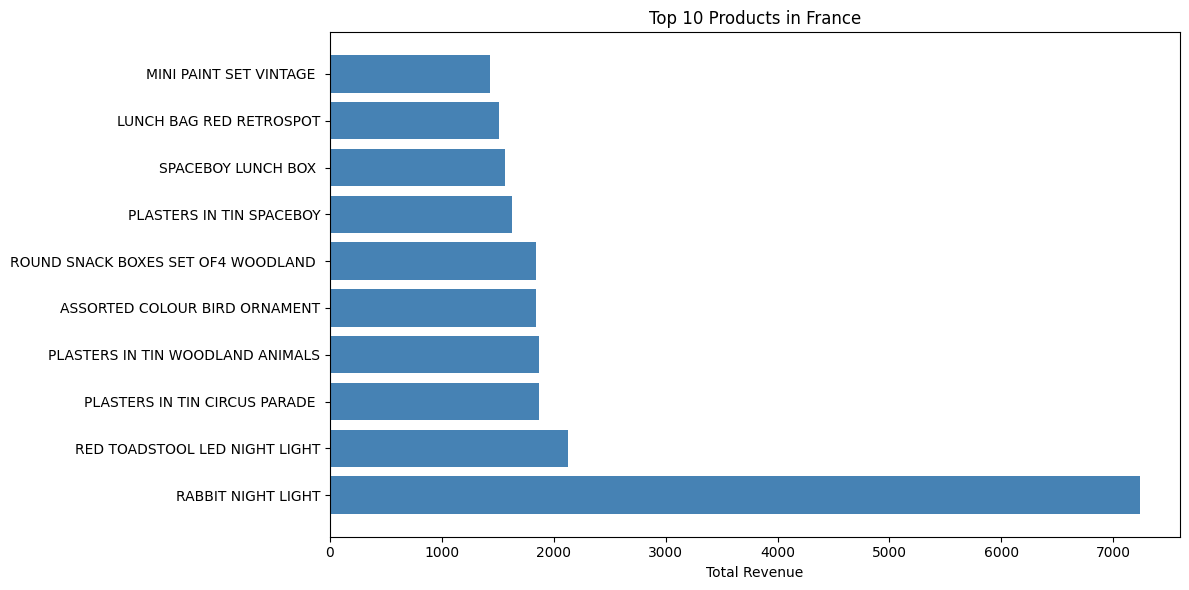

In [5]:
data['TotalPrice'] = data['Quantity'] * data['UnitPrice']

data = data.dropna(subset=['Country', 'Description'])
data = data[data['TotalPrice'] > 0]

top_5_countries = data.groupby('Country')['TotalPrice'].sum().nlargest(5).index.tolist()

for country in top_5_countries:
    country_data = data[data['Country'] == country]
    top_products = country_data.groupby('Description')['TotalPrice'].sum().nlargest(10)

    plt.figure(figsize=(12, 6))
    plt.barh(top_products.index, top_products.values, color='steelblue')
    plt.title(f'Top 10 Products in {country}')
    plt.xlabel('Total Revenue')
    plt.tight_layout()
    plt.show()

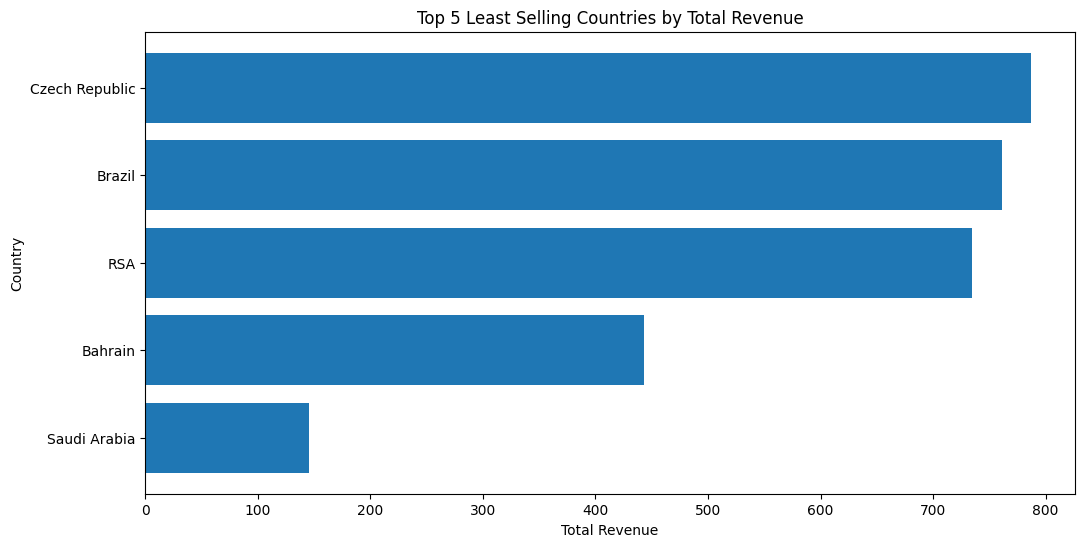

In [6]:
least_countries = data.groupby('Country')['TotalPrice'].sum().nsmallest(5)

plt.figure(figsize=(12, 6))
plt.barh(y=least_countries.index, width=least_countries.values)
plt.title('Top 5 Least Selling Countries by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.show()

Dashboard


In [16]:
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

product_analysis = (
    data.groupby("Description")
      .agg(Quantity=("Quantity","sum"), TotalPrice=("TotalPrice","sum"))
      .sort_values("TotalPrice", ascending=False)
      .reset_index()
)
top_10_products = product_analysis.head(10)

customer_analysis = (
    data.groupby("CustomerID")
      .agg(Total_Orders=("InvoiceNo","nunique"), Total_Spent=("TotalPrice","sum"))
      .sort_values("Total_Spent", ascending=False)
      .reset_index()
)
top_10_customers = customer_analysis.head(10).copy()
top_10_customers["CustomerID"] = top_10_customers["CustomerID"].astype(str)

country_analysis = (
    data.groupby("Country")
      .agg(Total_Revenue=("TotalPrice","sum"), Unique_Customers=("CustomerID","nunique"))
      .sort_values("Total_Revenue", ascending=False)
      .reset_index()
)
top_10_countries  = country_analysis.head(10)
top_5_countries   = country_analysis.head(5)
least_5_countries = country_analysis.nsmallest(5, "Total_Revenue")
country_pie_data  = country_analysis[country_analysis["Country"] != "United Kingdom"].head(10)

invoice_summary = data.groupby("InvoiceNo").agg(
    TotalPrice=("TotalPrice","sum"), Quantity=("Quantity","sum")
).reset_index()
aov        = round(invoice_summary["TotalPrice"].mean(), 2)
avg_items  = round(invoice_summary["Quantity"].mean(), 2)
kpi_df     = pd.DataFrame({"Metric": ["Average Order Value (AOV)", "Average Items Per Order"],
                            "Value":  [aov, avg_items]})

monthly_sales = (
    data.groupby(data["InvoiceDate"].dt.to_period("M"))["TotalPrice"]
      .sum()
)
monthly_sales.index = monthly_sales.index.astype(str)

daily_sales  = data.groupby(data["InvoiceDate"].dt.date)["TotalPrice"].sum()
hourly_sales = data.groupby("Hour")["TotalPrice"].sum().sort_index()

order_days  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_counts  = data["DayOfWeek"].value_counts().reindex(order_days).dropna()

filtered    = data[data["TotalPrice"] < data["TotalPrice"].quantile(0.99)]
corr        = data[["Quantity","UnitPrice","TotalPrice"]].corr()

x_idx  = np.arange(len(monthly_sales))
z_poly = np.polyfit(x_idx, monthly_sales.values, 1)
trend  = np.poly1d(z_poly)(x_idx)

top_5_idx   = country_analysis.head(5)["Country"].tolist()

BLUES   = px.colors.sequential.Blues[3:]
GREENS  = px.colors.sequential.Greens[3:]
PURPLES = px.colors.sequential.Purples[3:]
ORANGES = px.colors.sequential.Oranges[3:]
REDS    = px.colors.sequential.Reds[3:]
TEAL    = px.colors.sequential.Teal[3:]
QUAL    = px.colors.qualitative.Set2

TEMPLATE = "plotly_white"

fig = make_subplots(
    rows=14, cols=2,
    row_heights=[0.04,
                 0.09,
                 0.07,
                 0.07,
                 0.07,
                 0.07,
                 0.07,
                 0.07,
                 0.07,
                 0.07,
                 0.07,
                 0.07,
                 0.07,
                 0.07],
    subplot_titles=[
        "Total Revenue", "Total Orders",
        "Top 10 Products by Revenue", "Top 10 Products by Quantity Sold",
        "KPI Bar: AOV & Avg Items", "",
        "Top 10 Customers by Total Spending", "",
        "Top 5 Countries by Revenue", "Revenue Share Excl. UK (Pie)",
        "Top 10 Countries Excl. UK", "5 Least Selling Countries",
        "Monthly Sales Trend", "",
        "Trend Line (Linear Regression)", "",
        "Daily Sales Trend", "Sales by Hour of Day",
        "Price Distribution (excl. top 1%)", "Correlation Matrix",
        "Orders by Day of Week", "Top 10 Countries (all, bar)",
        "Top 10 Products – United Kingdom", "Top 10 Products – Netherlands",
        "Top 10 Products – EIRE", "Top 10 Products – Germany",
        "Top 10 Products – France", "",
    ],
    specs=[
        [{"type":"indicator"},     {"type":"indicator"}],
        [{"type":"xy"},            {"type":"xy"}],
        [{"type":"xy","colspan":2},None],
        [{"type":"xy","colspan":2},None],
        [{"type":"xy"},            {"type":"domain"}],
        [{"type":"xy"},            {"type":"xy"}],
        [{"type":"xy","colspan":2},None],
        [{"type":"xy","colspan":2},None],
        [{"type":"xy"},            {"type":"xy"}],
        [{"type":"xy"},            {"type":"xy"}],
        [{"type":"xy"},            {"type":"xy"}],
        [{"type":"xy"},            {"type":"xy"}],
        [{"type":"xy"},            {"type":"xy"}],
        [{"type":"xy"},            {"type":"xy"}]
    ],
    vertical_spacing=0.04,
    horizontal_spacing=0.08,
)

fig.add_trace(go.Indicator(
    mode="number", value=data["TotalPrice"].sum(),
    number={"prefix":"£","valueformat":",.0f"},
    title={"text":"Total Revenue"},
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode="number", value=data["InvoiceNo"].nunique(),
    number={"valueformat":","},
    title={"text":"Total Orders"},
), row=1, col=2)

t10r = top_10_products.sort_values("TotalPrice")
fig.add_trace(go.Bar(
    x=t10r["TotalPrice"], y=t10r["Description"],
    orientation="h",
    marker_color=BLUES, name="Revenue",
    hovertemplate="<b>%{y}</b><br>£%{x:,.0f}<extra></extra>",
), row=2, col=1)

t10q = top_10_products.sort_values("Quantity")
fig.add_trace(go.Bar(
    x=t10q["Quantity"], y=t10q["Description"],
    orientation="h",
    marker_color=GREENS, name="Quantity",
    hovertemplate="<b>%{y}</b><br>%{x:,} units<extra></extra>",
), row=2, col=2)

fig.add_trace(go.Bar(
    x=kpi_df["Metric"], y=kpi_df["Value"],
    marker_color=[ORANGES[-1], PURPLES[-1]], name="KPI",
    text=kpi_df["Value"].astype(str),
    textposition="outside",
    hovertemplate="<b>%{x}</b><br>%{y}<extra></extra>",
), row=3, col=1)

tc = top_10_customers.sort_values("Total_Spent")
fig.add_trace(go.Bar(
    x=tc["Total_Spent"], y=tc["CustomerID"].astype(str),
    orientation="h",
    marker_color=PURPLES, name="Customers",
    hovertemplate="Customer <b>#%{y}</b><br>£%{x:,.0f}<extra></extra>",
), row=4, col=1)

t5c = top_5_countries.sort_values("Total_Revenue")
fig.add_trace(go.Bar(
    x=t5c["Total_Revenue"], y=t5c["Country"],
    orientation="h",
    marker_color=ORANGES, name="Top 5 Countries",
    hovertemplate="<b>%{y}</b><br>£%{x:,.0f}<extra></extra>",
), row=5, col=1)

fig.add_trace(go.Pie(
    labels=country_pie_data["Country"],
    values=country_pie_data["Total_Revenue"],
    hole=0.4, name="Country Pie",
    marker_colors=QUAL,
    hovertemplate="<b>%{label}</b><br>£%{value:,.0f} (%{percent})<extra></extra>",
), row=5, col=2)

excl_uk = country_analysis[country_analysis["Country"] != "United Kingdom"].head(10).sort_values("Total_Revenue")
fig.add_trace(go.Bar(
    x=excl_uk["Total_Revenue"], y=excl_uk["Country"],
    orientation="h", marker_color=TEAL, name="Excl UK",
    hovertemplate="<b>%{y}</b><br>£%{x:,.0f}<extra></extra>",
), row=6, col=1)

l5 = least_5_countries.sort_values("Total_Revenue")
fig.add_trace(go.Bar(
    x=l5["Total_Revenue"], y=l5["Country"],
    orientation="h", marker_color=REDS, name="Least 5",
    hovertemplate="<b>%{y}</b><br>£%{x:,.2f}<extra></extra>",
), row=6, col=2)

fig.add_trace(go.Scatter(
    x=monthly_sales.index, y=monthly_sales.values,
    mode="lines+markers", fill="tozeroy",
    fillcolor="rgba(59,130,246,0.1)",
    line=dict(color="#3b82f6", width=2),
    marker=dict(size=5), name="Monthly",
    hovertemplate="<b>%{x}</b><br>£%{y:,.0f}<extra></extra>",
), row=7, col=1)

fig.add_trace(go.Scatter(
    x=monthly_sales.index, y=monthly_sales.values,
    mode="lines", line=dict(color="#3b82f6", width=2),
    name="Sales", hovertemplate="<b>%{x}</b><br>£%{y:,.0f}<extra></extra>",
), row=8, col=1)
fig.add_trace(go.Scatter(
    x=monthly_sales.index, y=trend,
    mode="lines", line=dict(color="#ef4444", width=2, dash="dot"),
    name="Trend", hovertemplate="Trend: £%{y:,.0f}<extra></extra>",
), row=8, col=1)

fig.add_trace(go.Scatter(
    x=daily_sales.index.astype(str), y=daily_sales.values,
    mode="lines", fill="tozeroy",
    fillcolor="rgba(139,92,246,0.1)",
    line=dict(color="#8b5cf6", width=1.2), name="Daily",
    hovertemplate="<b>%{x}</b><br>£%{y:,.0f}<extra></extra>",
), row=9, col=1)

fig.add_trace(go.Bar(
    x=[str(h)+":00" for h in hourly_sales.index],
    y=hourly_sales.values,
    marker_color="#f59e0b", name="Hourly",
    hovertemplate="<b>%{x}</b><br>£%{y:,.0f}<extra></extra>",
), row=9, col=2)

fig.add_trace(go.Histogram(
    x=filtered["TotalPrice"], nbinsx=50,
    marker_color="#0d9488", opacity=0.8, name="Price dist",
    hovertemplate="£%{x:.1f}<br>Count: %{y}<extra></extra>",
), row=10, col=1)

fig.add_trace(go.Heatmap(
    z=corr.values,
    x=corr.columns.tolist(), y=corr.index.tolist(),
    colorscale="Blues", showscale=False,
    text=[[f"{v:.2f}" for v in row] for row in corr.values],
    texttemplate="%{text}", textfont={"size":13},
    hovertemplate="%{y} × %{x}: %{z:.3f}<extra></extra>",
), row=10, col=2)

fig.add_trace(go.Bar(
    x=dow_counts.index.tolist(), y=dow_counts.values,
    marker_color=QUAL, name="Day of week",
    hovertemplate="<b>%{x}</b><br>%{y:,} orders<extra></extra>",
), row=11, col=1)

all_countries = country_analysis.sort_values("Total_Revenue")
fig.add_trace(go.Bar(
    x=all_countries["Total_Revenue"], y=all_countries["Country"],
    orientation="h", marker_color=ORANGES[-1], name="All countries",
    hovertemplate="<b>%{y}</b><br>£%{x:,.0f}<extra></extra>",
), row=11, col=2)

country_positions = {
    "United Kingdom": (12, 1),
    "Netherlands":    (12, 2),
    "EIRE":           (13, 1),
    "Germany":        (13, 2),
    "France":         (14, 1),
}
country_colors = [BLUES, GREENS, PURPLES, ORANGES, TEAL]

for (country, (r, c)), colors in zip(country_positions.items(), country_colors):
    cd = data[data["Country"] == country]
    tp = cd.groupby("Description")["TotalPrice"].sum().nlargest(10).sort_values()
    fig.add_trace(go.Bar(
        x=tp.values, y=tp.index.tolist(),
        orientation="h", marker_color=colors, name=country,
        hovertemplate=f"<b>%{{y}}</b><br>£%{{x:,.0f}}<extra>{country}</extra>",
    ), row=r, col=c)

fig.update_layout(
    template=TEMPLATE,
    title=dict(
        text="<b>Online Retail Analytics Dashboard</b>",
        font=dict(size=22), x=0.5, xanchor="center",
    ),
    height=15000,
    showlegend=False,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(family="system-ui, sans-serif", size=11),
    margin=dict(t=60, b=40, l=40, r=40),
)

fig.update_xaxes(gridcolor="rgba(255,255,255,0.06)", zeroline=False)
fig.update_yaxes(gridcolor="rgba(255,255,255,0.06)", zeroline=False)

fig.show()
